In [36]:
import numpy as np
from scipy.optimize import newton
import CoolProp.CoolProp as cp
import fluids as fl
from Pumps.ZX115.ZX115PumpFit import Pa4m3s
import pandas as pd

In [37]:
def nu_from_T(T):
    return  1.3686547347844438e-06*np.exp(1913.7989961446747/T)

In [43]:
def diametro_equivalente_rectangular(a, b):
    """
    Calcula el diámetro equivalente (D_E) de un ducto rectangular 
    basado en la ecuación de Owen (1954).
    
    Parámetros:
    a (float): Ancho del rectángulo (width)
    b (float): Alto del rectángulo (height)
    
    Retorna:
    D_E (float): Diámetro equivalente
    """
    
    # Aseguramos que 'a' sea la dimensión mayor para que a/b >= 1
    # Físicamente, rotar el ducto no cambia su diámetro equivalente
    if a < b:
        a, b = b, a
        
    ratio = a / b
    
    # Arrays con los valores de la tabla
    # Para el infinito (∞), usamos un valor suficientemente grande (ej. 1000) 
    # para que la interpolación funcione correctamente.
    relacion_ab = np.array([1, 1.5, 2, 3, 4, 5, 10, 1000])
    factor_K = np.array([28.45, 20.43, 17.49, 15.19, 14.24, 13.73, 12.81, 12.0])
    
    # Interpolamos el valor de K según nuestro ratio actual
    K = np.interp(ratio, relacion_ab, factor_K)
    
    # Aplicamos la ecuación (6-51) de la imagen
    # D_E = ((128 * a * b^3) / (pi * K))^(1/4)
    D_E = ((128 * a * (b**3)) / (np.pi * K))**(1/4)
    
    return D_E, K

In [38]:
# Parámetros geométricos y de accesorios
K_inlet = fl.fittings.entrance_distance(12.7e-3, 1.5e-3)
K_valve = 0
K_no_retorno = fl.fittings.K_tilting_disk_check_valve_Crane(12.7e-3, 15)
print(K_no_retorno)
K_oulet = fl.fittings.exit_normal()
print(K_oulet)
print(K_inlet)
m1_din = 12.7e-3
m1_l = 0.30
m2_din = 12.7e-3
m2_l = 0.3
d_botella = 11.5e-2

A_botella = np.pi * (d_botella**2) / 4
A_m1 = np.pi * (m1_din**2) / 4
A_m2 = np.pi * (m2_din**2) / 4

e_plastic = fl.friction.material_roughness("Plastic")
e_glass = fl.friction.material_roughness("glass")
print(e_glass)

# Definición del tanque cilíndrico acostado: Diámetro = 70mm, Largo = 100mm
L_tanque = 100e-3
tanque = fl.TANK(D=70e-3, L=L_tanque, horizontal=True, sideA=None, sideB=None)

3.2569427762557432
1.0
0.5700000000000001
1e-05


In [ ]:
# Modificamos la función para que opcionalmente nos devuelva el diagnóstico técnico y presiones
def evaluar_regimen_sistema(Q, mu, rho, hi, Vf, retornar_diagnostico=False):
    if Q <= 0:
        return (0.0 if not retornar_diagnostico else ({}, {}))
        
    # Sección 0: Botella
    v0 = Q / A_botella
    h0 = hi
    Re0 = fl.Reynolds(V=v0, D=d_botella, rho=rho, mu=mu)
    fd0 = fl.friction_factor(Re=Re0, eD=e_glass/d_botella) 
    loss0 = fd0 * (h0 / d_botella) * (rho * v0**2 / 2)
    
    # Sección 1: Manguera 1
    v1 = Q / A_m1
    h1 = 0.3
    Re1 = fl.Reynolds(V=v1, D=m1_din, rho=rho, mu=mu)
    loss_inlet = K_inlet * (rho * v1**2 / 2)
    fd1 = fl.friction_factor(Re=Re1, eD=e_plastic/m1_din) 
    loss1 = fd1 * (m1_l / m1_din) * (rho * v1**2 / 2)
    
    # Sección 2: Manguera 2
    v2 = Q / A_m2
    Re2 = fl.Reynolds(V=v2, D=m2_din, rho=rho, mu=mu)
    fd2 = fl.friction_factor(Re=Re2, eD=e_plastic/m2_din) 
    loss2 = fd2 * (m2_l / m2_din) * (rho * v2**2 / 2)
    loss_valve = K_valve * (rho * v2**2 / 2)
    loss_outlet = K_oulet * (rho * v2**2 / 2)
    
    # Sección Final: Tanque horizontal
    hf = tanque.h_from_V(Vf)
    Af = tanque.A_cross_sectional(hf)
    ancho = Af/L_tanque if L_tanque > 0 else 0.0
    vf = Q / Af if Af > 0 else 0.0
    
    # Reynolds para el tanque
    if vf > 0 and ancho > 0:
        D_hidraulico_tanque = (1.3 * (Af)**0.625) / ((ancho * L_tanque)**0.25)
        D_hidraulico_tanque1 = D_hidraulico_tanque(a = L_tanque, b=ancho)
        print(D_hidraulico_tanque, D_hidraulico_tanque1)
        Re_tanque = fl.Reynolds(V=vf, D=D_hidraulico_tanque, rho=rho, mu=mu)
    else:
        Re_tanque = 0.0
    
    dh = h1 + hf - h0
    delta_p = (loss0 + loss1 + loss2 + loss_inlet + loss_valve + loss_outlet 
               + (rho * vf**2 / 2 - rho * v0**2 / 2)
               + dh * rho * 9.81)

    # -------------------------------------------------------------
    # CÁLCULO DE PRESIONES ESTÁTICAS HACIA ADELANTE (Manométricas en Pa)
    # -------------------------------------------------------------
    # 1. Presión al entrar a la Manguera 1 (Fondo de la botella, z=0)
    P_entrada_m1 = rho * 9.81 * h0 + (rho * v0**2 / 2) - (rho * v1**2 / 2) - loss0 - loss_inlet
    
    # 2. Presión de Succión (Fin Manguera 1, justo antes de la bomba, z=h1)
    P_succion = P_entrada_m1 - rho * 9.81 * h1 - loss1
    
    # 3. Aporte exacto de la bomba según la curva ajustada
    Aporte_Bomba = Pa4m3s(Q)
    
    # 4. Presión de Descarga (Inicio Manguera 2, justo después de la bomba)
    P_descarga = P_succion + Aporte_Bomba
    
    # 5. Presión al entrar al tanque (Fin Manguera 2, z=h1)
    P_entrada_tanque = P_descarga - loss2 - loss_valve
    
    # 6. Presión final en la superficie del líquido en el tanque
    # Si el sistema está perfectamente balanceado, esto debe ser ≈ 0 Pa
    P_superficie_final = P_entrada_tanque - loss_outlet - rho * 9.81 * hf - (rho * vf**2 / 2) + (rho * v2**2 / 2)

    if retornar_diagnostico:
        Re_critico = 2000
        
        def clasificar(re):
            if re < 2000: return "Laminar"
            else: return "Turbulento"
            
        datos_regimen = {
            "Segmento": ["Botella (Tramo 0)", "Manguera 1 (Tramo 1)", "Manguera 2 (Tramo 2)", "Tanque (Salida)"],
            "Velocidad (m/s)": [v0, v1, v2, vf],
            "Reynolds Calculado": [Re0, Re1, Re2, Re_tanque],
            "Reynolds Crítico": [Re_critico, Re_critico, Re_critico, Re_critico],
            "Régimen": [clasificar(Re0), clasificar(Re1), clasificar(Re2), clasificar(Re_tanque)]
        }
        
        # Diccionario con el ruteo completo mostrando el aporte explícito
        datos_presiones = {
            "Ubicación en el Sistema": [
                "0. Superficie Botella", 
                "1. Entrada Manguera 1", 
                "2. Succión Bomba", 
                "--> Aporte de Bomba (ΔP)",
                "3. Descarga Bomba", 
                "4. Entrada al Tanque", 
                "5. Superficie Tanque (Error Numérico)"
            ],
            "Presión Estática (Pa)": [
                0.0, 
                P_entrada_m1, 
                P_succion, 
                Aporte_Bomba, 
                P_descarga, 
                P_entrada_tanque, 
                P_superficie_final
            ]
        }
        return delta_p, datos_regimen, datos_presiones
        
    return delta_p

In [5]:
# 1. Propiedades del Fluido
fluido = "Water"
T_celcius = 16               # Temperatura en °C
P_pascales = 101325.0           # Presión absoluta en Pa (1 atm)
T_kelvin = T_celcius + 273.15   

# Cálculo exacto de Densidad (rho) y Viscosidad Dinámica (mu)
rho_agua = cp.PropsSI('D', 'T', T_kelvin, 'P', P_pascales, fluido)   # kg/m³
#mu_agua = cp.PropsSI('V', 'T', T_kelvin, 'P', P_pascales, fluido)    # Pa*s
mu_agua = nu_from_T(T_kelvin)


# 2. Condiciones Hidrostáticas
hi_actual = 0.2      # Altura inicial en la botella (m)
Vf_actual = 1e-6   # Volumen actual en el tanque horizontal (m³)

# 3. Curva de la Bomba
def presion_bomba(Q):
    return Pa4m3s(Q)

# 4. Función de residuo para Newton-Raphson: Bomba - Sistema = 0
def funcion_objetivo_diagnostico(Q):
    dP_bomba = presion_bomba(Q)
    dP_sistema = evaluar_regimen_sistema(Q, mu_agua, rho_agua, hi_actual, Vf_actual)
    return dP_bomba - dP_sistema

# 5. Ejecución del Solver
Q_inicial = 5e-4 

try:
    # Resolvemos la ecuación encontrando la raíz
    Q_operacion = newton(funcion_objetivo_diagnostico, Q_inicial)
    
    print("==========================================================")
    print("      PUNTO DE OPERACIÓN ENCONTRADO (NEWTON-RAPHSON)     ")
    print("==========================================================")
    print(f"Caudal de operación (Q) : {Q_operacion:.6e} m³/s")
    print(f"Caudal en Litros/min    : {Q_operacion * 60000:.3f} L/min")
    print(f"Presión entregada       : {presion_bomba(Q_operacion):.2f} Pa")
    print("==========================================================")
    
    # 6. Extracción de diagnóstico (AHORA DESEMPAQUETAMOS LOS 3 VALORES)
    _, info_regimen, info_presiones = evaluar_regimen_sistema(Q_operacion, mu_agua, rho_agua, hi_actual, Vf_actual, retornar_diagnostico=True)
    
    df_diagnostico = pd.DataFrame(info_regimen)
    df_presiones = pd.DataFrame(info_presiones)
    
    print("\n==========================================================")
    print(f"          DIAGNÓSTICO DE RÉGIMEN DE FLUJO                 ")
    print("==========================================================")
    display(df_diagnostico.style.hide(axis='index'))
    
    print("\n==========================================================")
    print(f"            MAPA DE PRESIONES ESTÁTICAS                   ")
    print("==========================================================")
    # Mostramos las presiones formateadas a 2 decimales para mayor limpieza
    display(df_presiones.style.hide(axis='index').format({"Presión Estática (Pa)": "{:.2f}"}))
    
except RuntimeError as e:
    print(f"El método numérico no logró converger: {e}")

      PUNTO DE OPERACIÓN ENCONTRADO (NEWTON-RAPHSON)     
Caudal de operación (Q) : 2.014096e-05 m³/s
Caudal en Litros/min    : 1.208 L/min
Presión entregada       : 1028.53 Pa

          DIAGNÓSTICO DE RÉGIMEN DE FLUJO                 


Segmento,Velocidad (m/s),Reynolds Calculado,Reynolds Crítico,Régimen
Botella (Tramo 0),0.001939,217.306577,2000,Laminar
Manguera 1 (Tramo 1),0.158995,1967.736717,2000,Laminar
Manguera 2 (Tramo 2),0.158995,1967.736717,2000,Laminar
Tanque (Salida),0.012468,1417.842041,2000,Laminar



            MAPA DE PRESIONES ESTÁTICAS                   


Ubicación en el Sistema,Presión Estática (Pa)
0. Superficie Botella,0.00
1. Entrada Manguera 1,1940.11
2. Succión Bomba,-1009.49
--> Aporte de Bomba (ΔP),1028.53
3. Descarga Bomba,19.04
4. Entrada al Tanque,9.34
5. Superficie Tanque (Error Numérico),-0.00


  INICIANDO SIMULACIÓN TRANSITORIA CON LÍMITE Re = 2000...

             REPORTE DE RÉGIMEN DE FLUJO                  
Reynolds MÁXIMO en Manguera 1 (6.6mm): 1975
 -> La Manguera 1 se mantuvo LAMINAR todo el tiempo (Re < 2000).

Reynolds MÁXIMO en Manguera 2 (12mm) : 1975
 -> La Manguera 2 se mantuvo LAMINAR todo el tiempo (Re < 2000).



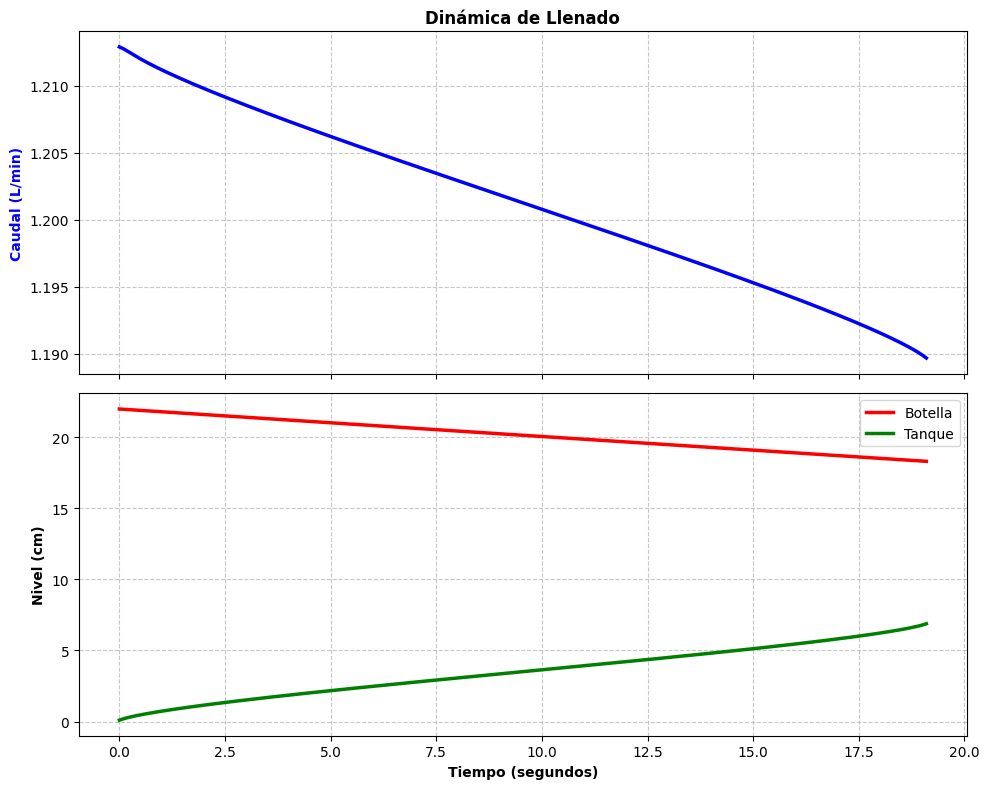

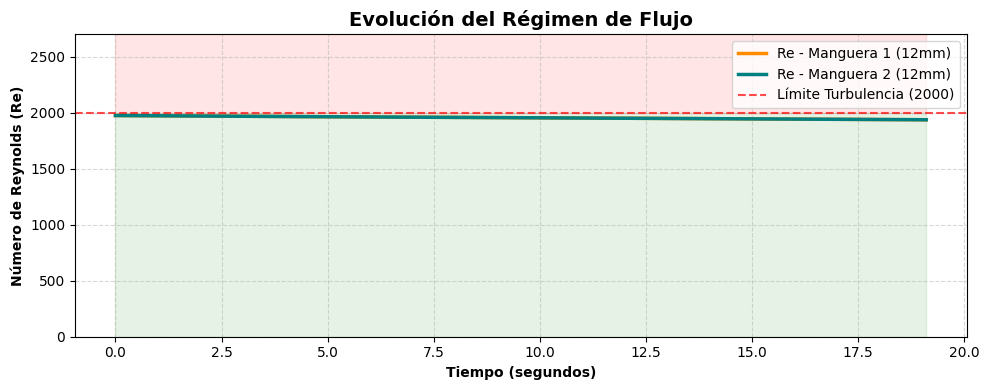

In [40]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import newton

# =========================================================================
# 1. PARÁMETROS INICIALES
# =========================================================================
dt = 0.1
t_actual = 0.0

h_botella_t = 0.22
V_tanque_t =  1e-6
radio_tanque = 70e-3 / 2
V_tanque_max = np.pi * (radio_tanque**2) * L_tanque

hist_t, hist_Q, hist_h_bot, hist_h_tan, hist_V_tan = [], [], [], [], []
hist_Re_m1, hist_Re_m2 = [], []

Q_estimado = 5e-4 

print("==========================================================")
print("  INICIANDO SIMULACIÓN TRANSITORIA CON LÍMITE Re = 2000...")
print("==========================================================")

# =========================================================================
# 2. BUCLE DE INTEGRACIÓN NUMÉRICA
# =========================================================================
while V_tanque_t < V_tanque_max and h_botella_t > 0:
    
    def funcion_transitoria(Q):
        dP_b = presion_bomba(Q)
        dP_s = evaluar_regimen_sistema(Q, mu_agua, rho_agua, h_botella_t, V_tanque_t)
        return dP_b - dP_s
        
    try:
        Q_actual = newton(funcion_transitoria, Q_estimado)
        Q_estimado = Q_actual 
        
        if Q_actual <= 0: break
            
    except RuntimeError:
        break
        
    # Extraemos los datos del instante actual
    _, info_reg,_ = evaluar_regimen_sistema(Q_actual, mu_agua, rho_agua, h_botella_t, V_tanque_t, retornar_diagnostico=True)
    
    Re_m1_actual = info_reg['Reynolds Calculado'][1]
    Re_m2_actual = info_reg['Reynolds Calculado'][2]
    
    h_tanque_actual = tanque.h_from_V(V_tanque_t)
    
    # Guardamos historia
    hist_t.append(t_actual)
    hist_Q.append(Q_actual * 60000)
    hist_h_bot.append(h_botella_t * 100)     
    hist_h_tan.append(h_tanque_actual * 100) 
    hist_V_tan.append(V_tanque_t * 1e6)      
    hist_Re_m1.append(Re_m1_actual)
    hist_Re_m2.append(Re_m2_actual)
    
    # Avanzamos un dt
    V_desplazado = Q_actual * dt
    V_tanque_t += V_desplazado
    h_botella_t -= V_desplazado / A_botella  
    t_actual += dt

# =========================================================================
# 3. RESULTADOS FINALES
# =========================================================================
max_Re_m1 = max(hist_Re_m1)
max_Re_m2 = max(hist_Re_m2)

print("\n==========================================================")
print("             REPORTE DE RÉGIMEN DE FLUJO                  ")
print("==========================================================")
print(f"Reynolds MÁXIMO en Manguera 1 (6.6mm): {max_Re_m1:.0f}")
if max_Re_m1 >= 2000:
    print(" -> ¡CONFIRMADO! La Manguera 1 operó en régimen TURBULENTO (Re >= 2000).")
else:
    print(" -> La Manguera 1 se mantuvo LAMINAR todo el tiempo (Re < 2000).")

print(f"\nReynolds MÁXIMO en Manguera 2 (12mm) : {max_Re_m2:.0f}")
if max_Re_m2 >= 2000:
    print(" -> ¡CONFIRMADO! La Manguera 2 operó en régimen TURBULENTO (Re >= 2000).")
else:
    print(" -> La Manguera 2 se mantuvo LAMINAR todo el tiempo (Re < 2000).")
print("==========================================================\n")

# =========================================================================
# 4. GRÁFICOS
# =========================================================================
fig1, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
ax1.plot(hist_t, hist_Q, 'b-', linewidth=2.5)
ax1.set_ylabel('Caudal (L/min)', color='b', fontweight='bold')
ax1.set_title('Dinámica de Llenado', fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.7)

ax2.plot(hist_t, hist_h_bot, 'r-', linewidth=2.5, label='Botella')
ax2.plot(hist_t, hist_h_tan, 'g-', linewidth=2.5, label='Tanque')
ax2.set_ylabel('Nivel (cm)', fontweight='bold')
ax2.set_xlabel('Tiempo (segundos)', fontweight='bold')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Figura de Turbulencia
fig2, ax3 = plt.subplots(figsize=(10, 4))
ax3.plot(hist_t, hist_Re_m1, 'darkorange', linewidth=2.5, label='Re - Manguera 1 (12mm)')
ax3.plot(hist_t, hist_Re_m2, 'teal', linewidth=2.5, label='Re - Manguera 2 (12mm)')

# Línea divisoria en 2000
ax3.axhline(2000, color='red', linestyle='--', alpha=0.7, label='Límite Turbulencia (2000)')

# Zonas sombreadas (Rojo = Turbulento, Verde = Laminar)
limite_superior_y = max(max_Re_m1, 2500) + 200
ax3.fill_between(hist_t, 2000, limite_superior_y, color='red', alpha=0.1)
ax3.fill_between(hist_t, 0, 2000, color='green', alpha=0.1)

ax3.set_ylabel('Número de Reynolds (Re)', fontweight='bold')
ax3.set_xlabel('Tiempo (segundos)', fontweight='bold')
ax3.set_title('Evolución del Régimen de Flujo', fontweight='bold', fontsize=14)
ax3.legend(loc='upper right')
ax3.grid(True, linestyle='--', alpha=0.5)
ax3.set_ylim(0, limite_superior_y)

plt.tight_layout()
plt.show()

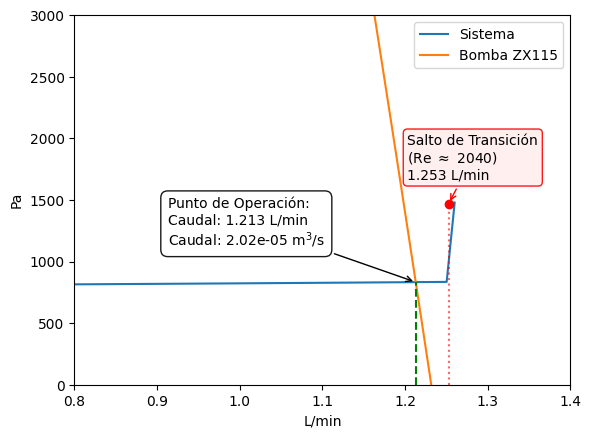

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

# 1. Definir el rango de caudales solicitado (0.000005 m3/s a 0.000021 m3/s)
caudales = np.linspace(0.000005, 0.000021, 100)

# Variables de entorno (Asegúrate de que coincidan con las de tu Jupyter)
hi, Vf = 0.22 , 1e-6
# mu_agua, rho_agua = 0.001, 1000 
# d_tuberia = 12.7e-3 # Diámetro de 12.7 mm

# 2. Generar las curvas
bomba = np.array([Pa4m3s(q) for q in caudales])
sistema = np.array([evaluar_regimen_sistema(q, mu_agua, rho_agua, hi, Vf) for q in caudales])

# 3. Encontrar matemáticamente el Punto de Operación (Intersección)
def buscar_interseccion(q):
    return evaluar_regimen_sistema(q[0], mu_agua, rho_agua, hi, Vf) - Pa4m3s(q[0])

Q_op = fsolve(buscar_interseccion, 0.000015)[0] 
P_op = Pa4m3s(Q_op)
Q_op_Lmin = Q_op * 60 * 1000

# -------------------------------------------------------------
# NUEVO: Cálculo exacto del punto de singularidad (Re = 2040)
# -------------------------------------------------------------
Q_crit_m3s = (2040 * np.pi * mu_agua * m1_din) / (4 * rho_agua)
Q_crit_Lmin = Q_crit_m3s * 60 * 1000
P_crit = evaluar_regimen_sistema(Q_crit_m3s, mu_agua, rho_agua, hi, Vf)

# 4. Configurar el gráfico
plt.figure()
plt.plot(caudales * 60 * 1000, sistema, label="Sistema")
plt.plot(caudales * 60 * 1000, bomba, label="Bomba ZX115")
plt.ylabel("Pa")
plt.xlabel("L/min")

# Ajuste de límites
plt.xlim(0.8, 1.4) 
plt.ylim(0, 3000)

# Líneas del punto de operación
plt.vlines(Q_op_Lmin, ymin=0, ymax=P_op, color="green", linestyle="--")

# Cuadro de texto Punto de Operación
texto_anotacion = (
    "Punto de Operación:\n"
    f"Caudal: {Q_op_Lmin:.3f} L/min\n"
    f"Caudal: {Q_op:.2e} m$^3$/s"
)

plt.annotate(
    texto_anotacion,
    xy=(Q_op_Lmin, P_op),               
    xytext=(Q_op_Lmin - 0.3, P_op + 300), 
    arrowprops=dict(arrowstyle="->", color="black"),
    bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="black", alpha=0.9)
)

# -------------------------------------------------------------
# NUEVO: Marcador y anotación de la Singularidad (Re=2040)
# -------------------------------------------------------------
# Dibujamos un punto rojo en la curva del sistema
plt.plot(Q_crit_Lmin, P_crit, marker='o', markersize=6, color="red", zorder=5)
plt.vlines(Q_crit_Lmin, ymin=0, ymax=P_crit, color="red", linestyle=":", alpha=0.6)

texto_singularidad = (
    "Salto de Transición\n"
    "(Re $\\approx$ 2040)\n"
    f"{Q_crit_Lmin:.3f} L/min"
)

plt.annotate(
    texto_singularidad,
    xy=(Q_crit_Lmin, P_crit),               
    xytext=(Q_crit_Lmin - 0.05, P_crit + 200), # Ajustado a la derecha para que no choque
    arrowprops=dict(arrowstyle="->", color="red"),
    bbox=dict(boxstyle="round,pad=0.3", facecolor="#ffeeee", edgecolor="red", alpha=0.9)
)

plt.legend()
plt.show()

In [18]:
print(fl.friction_factor(2040, e_plastic/m1_din) )

1.0233507846602783
